# <span style = 'color:Coral'>Decision Tree Classifier</span>
> Diabetes.csv

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, roc_auc_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier

In [2]:
df = pd.read_csv('diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
# features and target
x = df.iloc[:, 0:-1]
y = df.iloc[:, -1]

# data split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=42)

### Hyperparameter Tuning

In [4]:
param_grid = {
    "criterion": ["gini", "entropy", "log_loss"],
    "splitter": ["best", "random"],
    "max_depth": [3,5,7,10,None],
    "min_samples_split": [2,5,10],
    "min_samples_leaf": [1,2,4],
    "max_features": [None,"sqrt","log2"],
    "max_leaf_nodes": [None,10,20,30,50]
}

grid = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(x_train, y_train)

print("Best Parameters:\n")
print(grid.best_params_)

print("\nBest Cross Validation Score:")
print(round(grid.best_score_,4))

Best Parameters:

{'criterion': 'gini', 'max_depth': 5, 'max_features': 'log2', 'max_leaf_nodes': 30, 'min_samples_leaf': 2, 'min_samples_split': 5, 'splitter': 'best'}

Best Cross Validation Score:
0.7671


In [7]:
# best hyperparameters model
best_model = grid.best_estimator_
best_model

DecisionTreeClassifier(max_depth=5, max_features='log2', max_leaf_nodes=30,
                       min_samples_leaf=2, min_samples_split=5,
                       random_state=42)

In [ ]:
# model train
best_model.fit(x_train, y_train)
y_Pred = best_model.predict(x_test)

### Evaluation

Accuracy : 0.7208


              precision    recall  f1-score   support

           0       0.79      0.77      0.78        99
           1       0.60      0.64      0.62        55

    accuracy                           0.72       154
   macro avg       0.70      0.70      0.70       154
weighted avg       0.72      0.72      0.72       154



Axes(0.125,0.11;0.62x0.77)


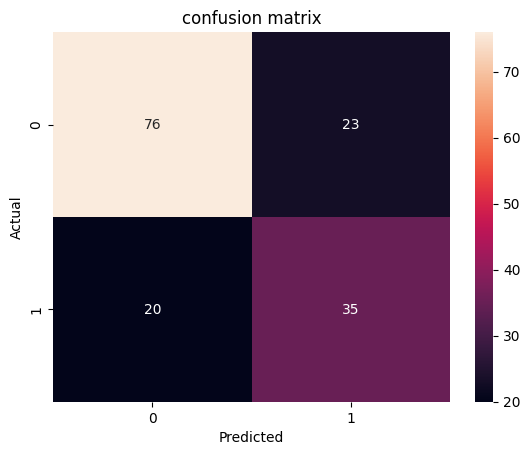

In [11]:
# model evaluation
print("Accuracy :", round(accuracy_score(y_test, y_Pred),4))
print('\n')
print(classification_report(y_test, y_Pred))
print('\n')
print(sns.heatmap(confusion_matrix(y_test, y_Pred), annot = True))
plt.title('confusion matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

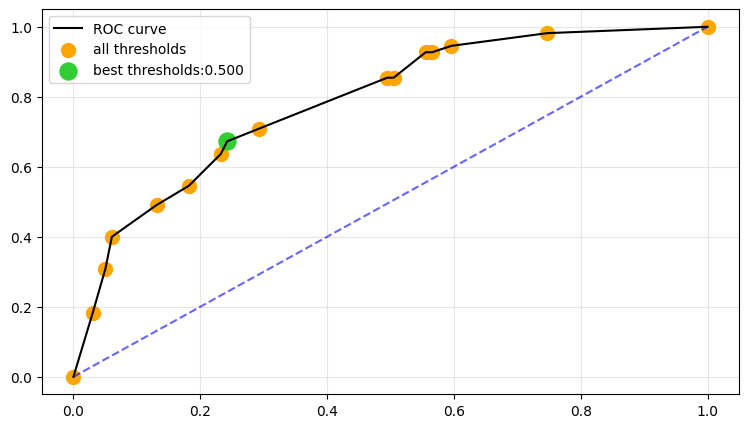

AUC score:  0.7858585858585859


In [23]:
# ROC curve
# Probability for positive class (Diabetes = 1)
y_score = best_model.predict_proba(x_test)[:, 1]

# ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_score)

# AUC Score
auc_score = roc_auc_score(y_test, y_score)

# best threshold
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]

plt.figure(figsize=(9,5))
plt.plot([0,1], [0,1], ls = 'dashed', color = 'blue', alpha=0.6)
plt.plot(fpr, tpr, color = 'k', label = 'ROC curve')
plt.scatter(fpr, tpr, color = 'orange', s = 100, label = 'all thresholds')
plt.scatter(fpr[optimal_idx], tpr[optimal_idx], color = 'limegreen', s = 150, label = f'best thresholds:{optimal_threshold:.3f}')
plt.legend()
plt.grid(True, alpha = 0.3)
plt.show()

print('AUC score: ',auc_score)

### Feature Importance

In [24]:
feature_importance = pd.DataFrame({
    'Feature':x.columns,
    'Importance':best_model.feature_importances_
})

feature_importance

,Feature,Importance
0,Pregnancies,0.025489
1,Glucose,0.354408
2,BloodPressure,0.054826
3,SkinThickness,0.028760
4,Insulin,0.036802
5,BMI,0.149328
6,DiabetesPedigreeFunction,0.076484
7,Age,0.273904


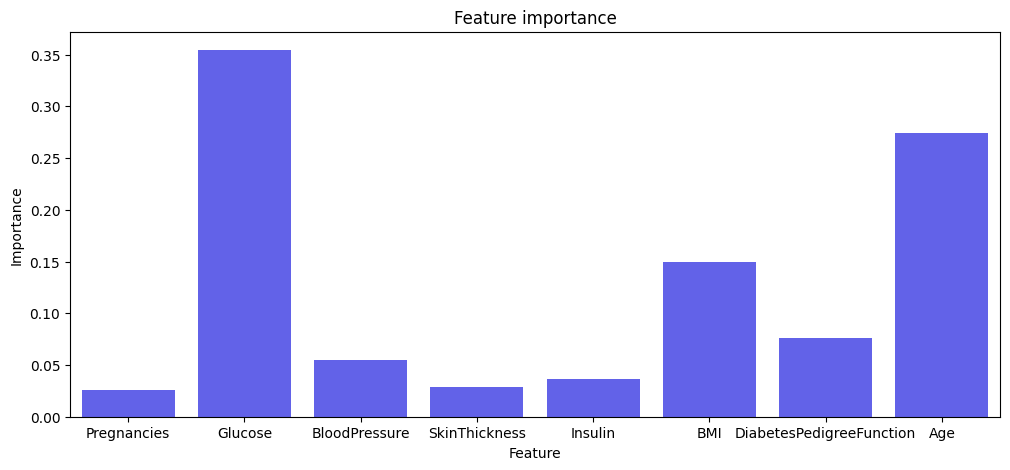

In [35]:
plt.figure(figsize=(12,5))
sns.barplot(
    data = feature_importance,
    x = 'Feature',
    y = 'Importance',
    color = 'blue',
    alpha = 0.7,
)
plt.title('Feature importance')
plt.show()

In [33]:
# reduced features 
selected_features = feature_importance[feature_importance['Importance'] > 0.04]['Feature'].to_list()
selected_features

['Glucose', 'BloodPressure', 'BMI', 'DiabetesPedigreeFunction', 'Age']

In [38]:
x_reduced = df[selected_features]

# train test split
x_trainr, x_testr, y_trainr, y_testr = train_test_split(x_reduced,y,test_size=0.2, random_state=42)

In [37]:
# model train
model_reduced = DecisionTreeClassifier(random_state=42,
                                       **grid.best_params_)
model_reduced.fit(x_trainr, y_trainr)

DecisionTreeClassifier(max_depth=5, max_features='log2', max_leaf_nodes=30,
                       min_samples_leaf=2, min_samples_split=5,
                       random_state=42)

In [39]:
y_Predr = model_reduced.predict(x_testr)
print("Reduced Dataset Accuracy:",
      round(accuracy_score(y_testr, y_Predr),4))

Reduced Dataset Accuracy: 0.7727


In [41]:
print("Enter Patient Details:\n")

preg = int(input("Pregnancies: "))
glucose = float(input("Glucose: "))
bp = float(input("Blood Pressure: "))
skin = float(input("Skin Thickness: "))
insulin = float(input("Insulin: "))
bmi = float(input("BMI: "))
dpf = float(input("Diabetes Pedigree Function: "))
age = int(input("Age: "))

user_data = pd.DataFrame({
    'Pregnancies':[preg],
    'Glucose':[glucose],
    'BloodPressure':[bp],
    'SkinThickness':[skin],
    'Insulin':[insulin],
    'BMI':[bmi],
    'DiabetesPedigreeFunction':[dpf],
    'Age':[age]
})

prediction = best_model.predict(user_data)

if prediction[0] == 1:
    print(f"\nPrediction : {prediction}(Patient is likely Diabetic.)")
else:
    print(f"\nPrediction : {prediction}(Patient is likely Non-Diabetic.)")

Enter Patient Details:


Prediction : [0](Patient is likely Non-Diabetic.)
